# GrC Image Matting on MIAS - Layer 1 and Layer 2 Templates

Builds the Layer 1 fuzzy texture representation at every patch scale, makes the image-level train/test split, and learns the K-Means texture templates that Layer 2 matches against.

Writes to Drive: `layer1_ms_lipw_{3,5,7}x{3,5,7}.npz`, `kmeans_templates.npy`, `template_meta.json`, `train_test_split.json`.

## Sections 5 & 6 - Layer 1 fuzzy texture extraction

Layer 1 encodes local texture as LIPW/LBPW maps. Two of the five modifications
are produced here:

| Scale | Role |
| --- | --- |
| 3×3 | Base-paper patch size, and the `baseline_3x3_manual` ablation arm |
| 5×5 | **Modification 2** — the single-scale ablation comparison point |
| 7×7 | Widest scale, contributes to the multi-scale stack |
| 3×3 + 5×5 + 7×7 | **Modification 4** — the multi-scale Layer 1 used by the full method |

In [ ]:
# Imports and config
!pip install -q opencv-python scikit-learn scipy tqdm joblib

import os, json, random, warnings, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
import joblib
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = "/content/drive/MyDrive/mias_grc_project"
CONFIG = json.load(open(os.path.join(DRIVE_ROOT, "config.json")))
globals().update(CONFIG)

SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)
print("Config loaded from Drive. Key values:")
print(f"  PATCH_SIZES  : {PATCH_SIZES}")
print(f"  PATCH_SINGLE : {PATCH_SINGLE}")
print(f"  K_CANDIDATES : {K_CANDIDATES}")
print(f"  LAMBDA_VAL   : {LAMBDA_VAL}")

Mounted at /content/drive
Config loaded from Drive. Key values:
  PATCH_SIZES  : [3, 5, 7]
  PATCH_SINGLE : 5
  K_CANDIDATES : [6, 8, 10]
  LAMBDA_VAL   : 5.0


In [ ]:
# Restore prev data required from notebook 1
final_df_loaded = pd.read_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"))
roi_arch    = np.load(os.path.join(PREPROCESSED_DIR, "rois.npz"))
trimap_arch = np.load(os.path.join(TRIMAPS_DIR, "trimaps.npz"))
metadata_df = pd.read_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"))

preprocessed_results = {
    iid: {
        'image_id': iid,
        'roi'     : roi_arch[iid],
        'trimap'  : trimap_arch[iid] if iid in trimap_arch.files else None,
    } for iid in roi_arch.files
}
for _, r in metadata_df.iterrows():
    if r['image_id'] in preprocessed_results:
        preprocessed_results[r['image_id']]['total_r']  = r['total_r']
        preprocessed_results[r['image_id']]['roi_size'] = r['roi_size']

print(f"Restored {len(preprocessed_results)} cases "
      f"({sum(1 for v in preprocessed_results.values() if v['trimap'] is not None)} with trimap)")

Restored 105 cases (55 with trimap)


In [ ]:
#  Layer 1 (vectorised)
def apply_layer1(roi, patch_size, lambda_val=None):

    """Layer 1 fuzzy texture extraction.
    LIPW: sigmoid of (pixel - 0.5), averaged over the patch.
    LBPW: fuzzy XOR against the centre pixel, then sigmoid, averaged.
    Returns (lipw_map, lbpw_map), both (H, W) float32."""
    
    lam = LAMBDA_VAL if lambda_val is None else lambda_val
    half = patch_size // 2
    padded = np.pad(roi, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (patch_size, patch_size))

    lipw = 1.0 / (1.0 + np.exp(-lam * (patches - 0.5)))
    lipw_map = lipw.mean(axis=(-2, -1)).astype(np.float32)

    centre = patches[:, :, half, half][:, :, None, None]
    centre = np.where(np.abs(centre - 0.5) < 1e-6, centre + 1e-6, centre)
    xor = patches + centre - 2 * patches * centre
    lbpw = 1.0 / (1.0 + np.exp(-lam * (xor - 0.5)))
    lbpw[:, :, half, half] = 0.0
    lbpw_map = lbpw.mean(axis=(-2, -1)).astype(np.float32)

    return lipw_map, lbpw_map

# Sanity check on ranges
_t = np.linspace(0, 1, 25).reshape(5, 5).astype(np.float32)
_l, _b = apply_layer1(_t, 3)
print(f"LIPW range on a 0..1 ramp: {_l.min():.4f} to {_l.max():.4f}")
print(f"LBPW range on a 0..1 ramp: {_b.min():.4f} to {_b.max():.4f}")
print("Note: sigmoid compresses values toward 0.5. This matters for Layer 2 "
      "and is why the matcher must use signed weights, not fixed 0.7/0.3 cuts.")

LIPW range on a 0..1 ramp: 0.1697 to 0.8303
LBPW range on a 0..1 ramp: 0.1613 to 0.4444
Note: sigmoid compresses values toward 0.5. This matters for Layer 2 and is why the matcher must use signed weights, not fixed 0.7/0.3 cuts.


In [ ]:
# Batch Layer 1 at every scale
layer1_maps = {ps: {} for ps in PATCH_SIZES}
t0 = time.time()

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="Layer 1"):
    iid = row['image_id']
    if iid not in preprocessed_results:
        continue
    roi = preprocessed_results[iid]['roi']
    for ps in PATCH_SIZES:
        lipw, lbpw = apply_layer1(roi, ps)
        layer1_maps[ps][iid] = {'lipw': lipw, 'lbpw': lbpw}

el = time.time() - t0
total = len(final_df_loaded) * len(PATCH_SIZES)
print(f"\nDone: {total} maps in {el:.1f}s ({total/el:.1f} maps/s)")

for ps in PATCH_SIZES:
    np.savez_compressed(os.path.join(OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz"),
                        **{k: v['lipw'] for k, v in layer1_maps[ps].items()})
    np.savez_compressed(os.path.join(OUTPUTS_DIR, f"layer1_ms_lbpw_{ps}x{ps}.npz"),
                        **{k: v['lbpw'] for k, v in layer1_maps[ps].items()})
print("Saved Layer 1 maps for all scales.")

Layer 1: 100%|██████████| 105/105 [00:06<00:00, 16.12it/s]



Done: 315 maps in 6.5s (48.3 maps/s)
Saved Layer 1 maps for all scales.


In [ ]:
# Contrast ratio per class (3x3 vs 5x5)
def contrast_ratio(lipw, trimap):
    if trimap is None:
        return None
    m, b = (trimap == 255), (trimap == 0)
    if m.sum() == 0 or b.sum() == 0:
        return None
    bg = lipw[b].mean()
    return float(lipw[m].mean() / bg) if bg > 1e-8 else None

print(f"{'Class':<8}{'Sample':<10}{'3x3':>10}{'5x5':>10}{'7x7':>10}")
print("-" * 48)
contrast_log = []
for cls in MASS_CLASSES:
    rows = final_df_loaded[final_df_loaded['class'] == cls]
    for _, r in rows.iterrows():
        iid = r['image_id']
        tm = preprocessed_results[iid]['trimap']
        if tm is None or iid not in layer1_maps[3]:
            continue
        vals = [contrast_ratio(layer1_maps[ps][iid]['lipw'], tm) for ps in PATCH_SIZES]
        if any(v is None for v in vals):
            continue
        print(f"{cls:<8}{iid:<10}" + "".join(f"{v:>10.2f}" for v in vals))
        contrast_log.append({'class': cls, 'image_id': iid,
                             **{f'contrast_{ps}x{ps}': v for ps, v in zip(PATCH_SIZES, vals)}})
        break

pd.DataFrame(contrast_log).to_csv(
    os.path.join(RESULTS_DIR, "layer1_contrast.csv"), index=False)
print("\nSaved layer1_contrast.csv")
print("A ratio near 1.0 means mass and background are texturally identical.")

Class   Sample           3x3       5x5       7x7
------------------------------------------------
CIRC    MDB001          4.84      4.83      4.81
SPIC    MDB145          1.13      1.12      1.12
MISC    MDB013          1.20      1.20      1.20

Saved layer1_contrast.csv
A ratio near 1.0 means mass and background are texturally identical.


## Sections 7 & 8 - Train/test split and K-Means template learning

**Modification 3.** Templates are learned from the data rather than hand-designed.

Two ordering constraints are of importance here:

1. The train/test split is made before the templates are learned, and K-Means
   sees patches from training images only. Learning templates on all images first
   would leak test-set texture statistics into the Layer 2 representation.
2. K-Means is fitted on **LBPW-derived** patches. Raw-intensity clustering collapsed to two or three dominant clusters at K = 16,
   because it separates on brightness rather than on texture.

K is selected by measuring actual mass-versus-background discrimination under the
signed matcher.

In [ ]:
# Train/test split at image level
mass_df = final_df_loaded[final_df_loaded['class'] != 'NORM'].reset_index(drop=True)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
tr, te = next(gss.split(mass_df, groups=mass_df['image_id']))

train_ids = set(mass_df.iloc[tr]['image_id'])
test_ids  = set(mass_df.iloc[te]['image_id'])

# NORM cases join the test side (they are only used for specificity)
norm_ids = set(final_df_loaded[final_df_loaded['class'] == 'NORM']['image_id'])
test_ids |= norm_ids

assert not (train_ids & test_ids), "leakage"
with open(os.path.join(RESULTS_DIR, "train_test_split.json"), 'w') as f:
    json.dump({'train_ids': sorted(train_ids), 'test_ids': sorted(test_ids)}, f, indent=2)

print(f"Train images : {len(train_ids)}")
print(f"Test images  : {len(test_ids)}  (includes {len(norm_ids)} NORM)")
print("Split is at image level, so no patch from one image appears in both sides.")

Train images : 38
Test images  : 67  (includes 50 NORM)
Split is at image level, so no patch from one image appears in both sides.


In [ ]:
# Extract LBPW patches for K-Means (train images only)
def extract_patches(ids, max_per_img=500):
    out = []
    rng = np.random.default_rng(SEED)
    half = PATCH_SINGLE // 2

    for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                       desc="patches"):
        iid, cls = row['image_id'], row['class']
        if cls == 'NORM' or iid not in ids or iid not in preprocessed_results:
            continue
        tm = preprocessed_results[iid]['trimap']
        if tm is None:
            continue
        lbpw = layer1_maps[PATCH_SINGLE][iid]['lbpw']
        padded = np.pad(lbpw, half, mode='reflect')

        for val in (255, 0):
            pos = np.argwhere(tm == val)
            if len(pos) == 0:
                continue
            if len(pos) > max_per_img:
                pos = pos[rng.choice(len(pos), max_per_img, replace=False)]
            for (i, j) in pos:
                p = padded[i:i+PATCH_SINGLE, j:j+PATCH_SINGLE]
                if p.shape == (PATCH_SINGLE, PATCH_SINGLE):
                    out.append(p.ravel())
    return np.array(out, dtype=np.float32)

all_patches = extract_patches(train_ids)
print(f"\nExtracted {all_patches.shape[0]} patches of dim {all_patches.shape[1]}")
print(f"Patch value range: {all_patches.min():.4f} to {all_patches.max():.4f}, "
      f"mean {all_patches.mean():.4f}")

patches: 100%|██████████| 105/105 [00:00<00:00, 827.58it/s]


Extracted 37634 patches of dim 25
Patch value range: 0.0728 to 0.5836, mean 0.2921


In [ ]:
def match_templates_signed(lipw_map, templates):
    h, w = lipw_map.shape
    K  = len(templates)
    ps = templates.shape[1]
    half = ps // 2

    padded = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf = patches.reshape(h*w, ps*ps).astype(np.float32)

    T  = templates.reshape(K, ps*ps).astype(np.float32)
    Tc = T - T.mean(axis=1, keepdims=True)
    W  = np.sign(Tc); W[W == 0] = 1.0
    Pc = pf - pf.mean(axis=1, keepdims=True)

    num   = Pc @ W.T
    denom = (np.linalg.norm(Pc, axis=1, keepdims=True) *
             np.linalg.norm(W, axis=1)[None, :] + 1e-8)
    return (((num/denom) + 1.0) * 0.5).reshape(h, w, K).astype(np.float32)

print("Signed matcher defined (same function used in notebook 3).")

Signed matcher defined (same function used in notebook 3).


In [ ]:
# Choose K using the real matcher
def score_k(k):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    km.fit(all_patches)
    tmpl = km.cluster_centers_.reshape(k, PATCH_SINGLE, PATCH_SINGLE).astype(np.float32)

    diffs, used = [], set()
    for cls in MASS_CLASSES:
        for _, r in final_df_loaded[final_df_loaded['class'] == cls].iterrows():
            iid = r['image_id']
            tm = preprocessed_results[iid]['trimap']
            if tm is None or iid not in layer1_maps[PATCH_SINGLE]:
                continue
            sm = match_templates_signed(layer1_maps[PATCH_SINGLE][iid]['lipw'], tmpl)
            m, b = (tm == 255), (tm == 0)
            if m.sum() == 0 or b.sum() == 0:
                continue
            d = sm[m].mean(axis=0) - sm[b].mean(axis=0)
            diffs.append(np.abs(d).max())
            used |= set(np.unique(np.argmax(sm, axis=2)).tolist())
            break
    return (float(np.mean(diffs)) if diffs else 0.0), len(used), km, tmpl

print(f"{'K':<5}{'mean |mass-bg| diff':>22}{'templates used':>18}")
print("-" * 46)
results = {}
for k in K_CANDIDATES:
    score, used, km, tmpl = score_k(k)
    results[k] = {'score': score, 'used': used, 'km': km, 'tmpl': tmpl}
    print(f"{k:<5}{score:>22.4f}{used:>12d} / {k}")

FINAL_K = max(results, key=lambda k: results[k]['score'])
print(f"\nSelected K = {FINAL_K} (highest discrimination with the real matcher)")
kmeans    = results[FINAL_K]['km']
templates = results[FINAL_K]['tmpl']

K       mean |mass-bg| diff    templates used
----------------------------------------------
6                    0.0905           6 / 6
8                    0.1098           8 / 8
10                   0.1176          10 / 10

Selected K = 10 (highest discrimination with the real matcher)


In [ ]:
tf = templates.reshape(FINAL_K, -1)
high = int((tf >= 0.7).sum()); low = int((tf <= 0.3).sum())
med  = int(((tf > 0.3) & (tf < 0.7)).sum()); tot = tf.size

print("Template value distribution:")
print(f"  HIGH (>=0.7) : {high:5d}  ({100*high/tot:5.1f} %)")
print(f"  LOW  (<=0.3) : {low:5d}  ({100*low/tot:5.1f} %)")
print(f"  MED          : {med:5d}  ({100*med/tot:5.1f} %)")
print(f"  range        : {tf.min():.4f} to {tf.max():.4f}, mean {tf.mean():.4f}")
print()
if med / tot > 0.8:
    print("NOTE: most template values sit in the medium band. This is expected for")
    print("centroids of sigmoid-compressed LBPW patches, and it is exactly why a")
    print("fixed 0.7/0.3 threshold matcher fails here. The signed matcher handles it.")

from scipy.spatial.distance import pdist, squareform
dm = squareform(pdist(tf))
iu = np.triu_indices(FINAL_K, 1)
print(f"\nPairwise template distance: min {dm[iu].min():.4f}, "
      f"mean {dm[iu].mean():.4f}, max {dm[iu].max():.4f}")

sm_test = match_templates_signed(
    layer1_maps[PATCH_SINGLE][list(train_ids)[0]]['lipw'], templates)
print(f"Templates winning on a sample image: "
      f"{len(np.unique(np.argmax(sm_test, axis=2)))} / {FINAL_K}")
assert len(np.unique(np.argmax(sm_test, axis=2))) > 2, \
    "Templates still collapsing - do not proceed."
print("Template health check passed.")

Template value distribution:
  HIGH (>=0.7) :     0  (  0.0 %)
  LOW  (<=0.3) :   150  ( 60.0 %)
  MED          :   100  ( 40.0 %)
  range        : 0.0789 to 0.4715, mean 0.2757


Pairwise template distance: min 0.1827, mean 0.8084, max 1.9557
Templates winning on a sample image: 10 / 10
Template health check passed.


In [ ]:
# Save templates
np.save(os.path.join(MODELS_DIR, "kmeans_templates.npy"), templates)
joblib.dump(kmeans, os.path.join(MODELS_DIR, "kmeans_model.joblib"))

template_meta = {
    'K'                : int(FINAL_K),
    'patch_size'       : int(PATCH_SINGLE),
    'source'           : 'LBPW patches from train images only',
    'n_patches'        : int(all_patches.shape[0]),
    'k_candidates'     : K_CANDIDATES,
    'selection_metric' : 'mean |mass-bg| score difference using the signed matcher',
    'value_range'      : [float(tf.min()), float(tf.max())],
    'value_mean'       : float(tf.mean()),
    'pct_medium_band'  : float(100*med/tot),
}
with open(os.path.join(MODELS_DIR, "template_meta.json"), 'w') as f:
    json.dump(template_meta, f, indent=2)

np.save(os.path.join(MODELS_DIR, "kmeans_templates_K16.npy"), templates)

print(f"Saved kmeans_templates.npy  (K = {FINAL_K}, honest filename)")
print("Saved template_meta.json")
print("Also wrote kmeans_templates_K16.npy as a back-compatible alias.")
print(json.dumps(template_meta, indent=2))

Saved kmeans_templates.npy  (K = 10, honest filename)
Saved template_meta.json
Also wrote kmeans_templates_K16.npy as a back-compatible alias.
{
  "K": 10,
  "patch_size": 5,
  "source": "LBPW patches from train images only",
  "n_patches": 37634,
  "k_candidates": [
    6,
    8,
    10
  ],
  "selection_metric": "mean |mass-bg| score difference using the signed matcher",
  "value_range": [
    0.07891714572906494,
    0.47154492139816284
  ],
  "value_mean": 0.2756505012512207,
  "pct_medium_band": 40.0
}


In [ ]:
# Multi-scale Layer 1 sanity check
def fuse_scales(iid, scales=None):
    scales = PATCH_SIZES if scales is None else scales
    return np.stack([layer1_maps[ps][iid]['lipw'] for ps in scales], axis=2)

sample_id = list(train_ids)[0]
stack = fuse_scales(sample_id)
print(f"Multi-scale stack shape: {stack.shape}  (H, W, {len(PATCH_SIZES)} scales)")
print(f"Per-scale mean: " + ", ".join(
    f"{ps}x{ps}={stack[:,:,i].mean():.4f}" for i, ps in enumerate(PATCH_SIZES)))
print("\nScales are saved separately, so notebook 3 can select or fuse any subset.")
print("This is what makes the ablation arms possible without recomputing Layer 1.")

Multi-scale stack shape: (118, 118, 3)  (H, W, 3 scales)
Per-scale mean: 3x3=0.6874, 5x5=0.6874, 7x7=0.6874

Scales are saved separately, so notebook 3 can select or fuse any subset.
This is what makes the ablation arms possible without recomputing Layer 1.


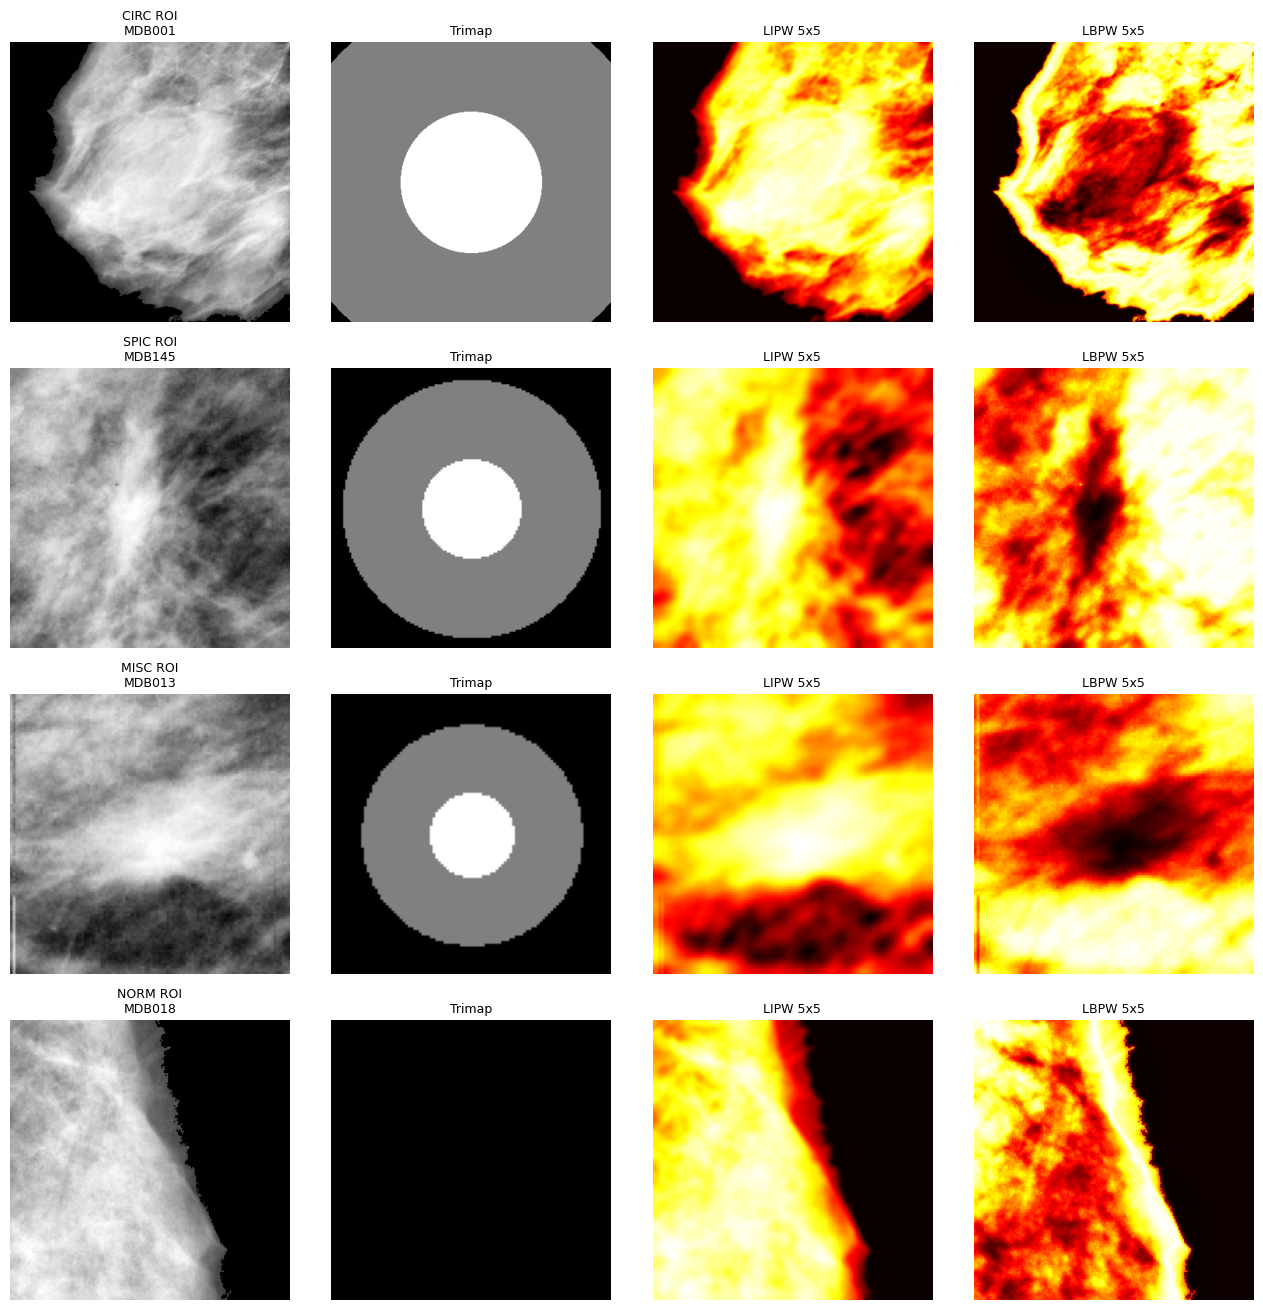

Saved section5_layer1_samples.png


In [ ]:
# Section 5/8 verification figure
picks = {}
for c in TARGET_CLASSES:
    for _, r in final_df_loaded[final_df_loaded['class'] == c].iterrows():
        if r['image_id'] in layer1_maps[3]:
            picks[c] = r['image_id']; break

n = len(picks)
fig, axes = plt.subplots(n, 4, figsize=(13, 3.3*n))
if n == 1: axes = axes.reshape(1, -1)
for r, (cls, iid) in enumerate(picks.items()):
    d = preprocessed_results[iid]
    axes[r,0].imshow(d['roi'], cmap='gray'); axes[r,0].set_title(f"{cls} ROI\n{iid}", fontsize=9)
    tm = d['trimap'] if d['trimap'] is not None else np.zeros_like(d['roi'])
    axes[r,1].imshow(tm, cmap='gray'); axes[r,1].set_title("Trimap", fontsize=9)
    axes[r,2].imshow(layer1_maps[PATCH_SINGLE][iid]['lipw'], cmap='hot')
    axes[r,2].set_title(f"LIPW {PATCH_SINGLE}x{PATCH_SINGLE}", fontsize=9)
    axes[r,3].imshow(layer1_maps[PATCH_SINGLE][iid]['lbpw'], cmap='hot')
    axes[r,3].set_title(f"LBPW {PATCH_SINGLE}x{PATCH_SINGLE}", fontsize=9)
    for c in range(4): axes[r,c].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section5_layer1_samples.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved section5_layer1_samples.png")

In [ ]:
# Final notebook verification
def verify_5to8():
    checks = {
        "Layer 1 all scales"      : all(len(layer1_maps[ps]) == len(final_df_loaded)
                                        for ps in PATCH_SIZES),
        "Layer 1 maps saved"      : all(os.path.exists(
            os.path.join(OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz")) for ps in PATCH_SIZES),
        "Split saved, no leakage" : (not (train_ids & test_ids)) and os.path.exists(
            os.path.join(RESULTS_DIR, "train_test_split.json")),
        "Templates saved"         : os.path.exists(os.path.join(MODELS_DIR,
                                                   "kmeans_templates.npy")),
        "Template meta saved"     : os.path.exists(os.path.join(MODELS_DIR,
                                                   "template_meta.json")),
        "K recorded matches array": json.load(open(os.path.join(MODELS_DIR,
                                    "template_meta.json")))['K'] == templates.shape[0],
        "Templates discriminate"  : len(np.unique(np.argmax(sm_test, axis=2))) > 2,
    }
    print("=" * 52); print("NOTEBOOK 2 (SECTIONS 5-8) VERIFICATION"); print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}"); ok = ok and v
    print("=" * 52)
    print("Proceed to notebook 3." if ok else "Fix failures first.")
    return ok

verify_5to8()